In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("datasets/housing.csv")
target = df['median_house_value']

df = df.drop(columns='median_house_value')

print(df.shape)

X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=5/85, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)


(20640, 9)
(16512, 9) (1032, 9) (3096, 9)


In [2]:
nan_percentage = X_train.isna().sum() / X_train.shape[0]
print(nan_percentage)
print()
nan_percentage = X_test.isna().sum() / X_test.shape[0]
print(nan_percentage)
print()
nan_percentage = X_val.isna().sum() / X_val.shape[0]
print(nan_percentage)
print()

longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
population            0.0
households            0.0
median_income         0.0
ocean_proximity       0.0
dtype: float64

longitude             0.00000
latitude              0.00000
housing_median_age    0.00000
total_rooms           0.00000
total_bedrooms        0.06686
population            0.00000
households            0.00000
median_income         0.00000
ocean_proximity       0.00000
dtype: float64

longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
population            0.0
households            0.0
median_income         0.0
ocean_proximity       0.0
dtype: float64



L'unica colonna con valori mancanti è total bedrooms

In [3]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train['total_bedrooms'] = imputer.fit_transform(X_train[['total_bedrooms']]).ravel()
X_test['total_bedrooms'] = imputer.transform(X_test[['total_bedrooms']]).ravel()
X_val['total_bedrooms'] = imputer.transform(X_val[['total_bedrooms']]).ravel()

In [4]:
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print(cat_cols)
print(num_cols)

print(X_train['ocean_proximity'].unique())

from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_val[cat_cols] = encoder.transform(X_val[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

['ocean_proximity']
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
['<1H OCEAN' 'NEAR BAY' 'INLAND' 'NEAR OCEAN' 'ISLAND']


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform='pandas')
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

In [6]:
corr = X_train[num_cols].corr()
n_cols = len(corr.columns)

for i in range(n_cols):
    for j in range(i+1, n_cols):
        c = abs(corr.iat[i,j])
        if c > 0.5:
            f1 = corr.columns[i]
            f2 = corr.columns[j]
            print(f"{f1} - {f2}: {c}")

longitude - latitude: 0.9245511231259306
total_rooms - total_bedrooms: 0.9297527024682195
total_rooms - population: 0.8585211433747123
total_rooms - households: 0.920112880802805
total_bedrooms - population: 0.8791017641990041
total_bedrooms - households: 0.9807028356877852
population - households: 0.9072358297518782


In [7]:
# from sklearn.cluster import FeatureAgglomeration

# agglo = FeatureAgglomeration(n_clusters=5).set_output(transform='pandas')

# X_train = agglo.fit_transform(X_train)
# X_val = agglo.transform(X_val)
# X_test = agglo.transform(X_test)

groups = [('longitude', 'latitude'), ('total_rooms', 'total_bedrooms', 'population', 'households')]

for group in groups:
    print(group)
    for df in [X_train, X_val, X_test]:
        df['_'.join(group)] = df[list(group)].mean(axis=1)
        df.drop(columns=list(group), inplace=True)


print(f"Nuova dimensione: {X_train.shape}")
print(X_train.head())

('longitude', 'latitude')
('total_rooms', 'total_bedrooms', 'population', 'households')
Nuova dimensione: (16512, 5)
       housing_median_age  median_income  ocean_proximity  longitude_latitude  \
4990             1.539551      -1.169100        -0.818296           -0.070211   
397              1.698088      -0.002411         1.303739           -0.152608   
11153           -0.838494      -0.547109        -0.818296           -0.020491   
18732           -0.045813      -0.968031        -0.110951            0.437841   
18691           -0.679958      -0.182957        -0.818296           -0.238240   

       total_rooms_total_bedrooms_population_households  
4990                                          -0.166823  
397                                           -0.705890  
11153                                         -0.769827  
18732                                         -0.734190  
18691                                          0.783984  


In [8]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso

lasso = Lasso()

selector = SelectFromModel(lasso)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)
X_val = selector.transform(X_val)

print("New shape", X_train.shape)

New shape (16512, 5)


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge = Ridge()
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_val)
print("Ridge MSE:", mean_squared_error(y_val, y_pred))
print("Ridge R2:", r2_score(y_val, y_pred))

rf = RandomForestRegressor(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
print("Random Forest MSE:", mean_squared_error(y_val, y_pred_rf))
print("Random Forest R2:", r2_score(y_val, y_pred_rf))

Ridge MSE: 5336221812.383503
Ridge R2: 0.5951644968679434
Random Forest MSE: 3916117465.2990503
Random Forest R2: 0.7029015209395053


In [10]:
import torch
from torch import nn
from torch.utils.data import Dataset, TensorDataset
import torchnn as utils

target_scaler = StandardScaler()
y_train = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = target_scaler.transform(y_test.values.reshape(-1, 1))
y_val = target_scaler.transform(y_val.values.reshape(-1, 1))

class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
        
train_dataloader, val_dataloader, test_dataloader = utils.make_dataloaders(
    MyDataset(X_train, y_train), MyDataset(X_val, y_val), MyDataset(X_test, y_test)
)

# train_dataloader, val_dataloader, test_dataloader = utils.make_dataloaders(
#     TensorDataset(torch.tensor(np.array(X_train), dtype=torch.float32), torch.tensor(np.array(y_train), dtype=torch.float32)),
#     TensorDataset(torch.tensor(np.array(X_val), dtype=torch.float32), torch.tensor(np.array(y_val), dtype=torch.float32)),
#     TensorDataset(torch.tensor(np.array(X_test), dtype=torch.float32), torch.tensor(np.array(y_test), dtype=torch.float32))
# )

/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape e tipo dei campioni: torch.Size([64, 5]), torch.float32
Shape e tipo delle etichette: torch.Size([64, 1]) torch.float32


In [11]:
class Net(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        w = 64
        
        self.layers = nn.Sequential(
            nn.Linear(X_train.shape[1], w),
            nn.ReLU(),
            
            nn.Dropout(0.2),
            nn.Linear(w, w),
            nn.ReLU(),
            
            nn.Dropout(0.2),
            nn.Linear(w, w),
            nn.ReLU(),
            
            nn.Linear(w, 1)
        )
        
    def forward(self, x):
        return self.layers(x)
    
model = Net()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=30)
early_stopping = utils.EarlyStopping(patience=10, min_delta=0.001)

In [12]:
def eval_loop(model, dataloader, device, loss_fn):
    model.eval()

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accuracy = 0.0, 0

    y_true = []
    y_pred = []
    with torch.no_grad():
        for X, y in dataloader:

            # Spostiamo esplicitamente i tensori sul device di computazione
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    test_loss /= num_batches

    # Calcoliamo il dizionario delle metriche per epoca
    epoch_metrics = {}
    epoch_metrics['mse'] = mean_squared_error(y_true, y_pred)
    epoch_metrics['r2'] = r2_score(y_true, y_pred)
    return test_loss, epoch_metrics, y_true, y_pred

import copy
class SaveBestModel:
    def __init__(self):
        self.best_loss = float('inf')
        self.best_model_state = None
        self.best_optimizer_state = None        
    def __call__(self, model, optimizer, epoch, train_loss, val_loss, metrics):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.model_state = copy.deepcopy(model.state_dict())
            self.optimizer_state = copy.deepcopy(optimizer.state_dict())
            self.epoch = epoch
            self.train_loss = train_loss
            self.val_loss = val_loss
            self.metrics = metrics
            
    def save(self, path):
        torch.save({
            'model_state_dict': self.model_state,
            'optimizer_state_dict': self.optimizer_state,
            'epoch': self.epoch,
            'train_loss': self.train_loss,
            'val_loss': self.val_loss,
            'metrics': self.metrics
        }, path)

In [13]:
from tqdm import trange
epochs = 30
train_batches = len(train_dataloader.batch_sampler)
train_loss = []
metrics = {
    'mse': [],
    'r2': []
}
save_best_model = SaveBestModel()
for epoch in range(1, epochs+1):
    pbar = trange(train_batches)
    pbar.set_description(desc='Epoch {:4d}'.format(epoch))
    
    epoch_train_loss = utils.train_loop(model, train_dataloader, optimizer, device, pbar, loss_fn=criterion)
    train_loss.append(epoch_train_loss)
    
    val_loss, epoch_metrics, _, _ = eval_loop(model, val_dataloader, device, loss_fn=criterion)
    print(f"Epoch {epoch} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {val_loss:.4f}")
    print(f"MSE: {epoch_metrics['mse']:.4f} - R2: {epoch_metrics['r2']:.4f}")
    
    metrics['mse'].append(epoch_metrics['mse'])
    metrics['r2'].append(epoch_metrics['r2'])
    
    save_best_model(model, optimizer, epoch, epoch_train_loss, val_loss, metrics)
    
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break
    
    if scheduler is not None:
        scheduler.step()
    
    

Epoch    1:   0%|          | 0/258 [00:00<?, ?it/s]/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch    1: 100%|██████████| 258/258 [00:00<00:00, 550.00it/s]


Epoch 1 - Train Loss: 0.4135 - Val Loss: 0.3481
MSE: 0.3576 - R2: 0.6375


Epoch    2:   0%|          | 0/258 [00:00<?, ?it/s]/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch    2: 100%|██████████| 258/258 [00:00<00:00, 583.08it/s]


Epoch 2 - Train Loss: 0.3758 - Val Loss: 0.3620
MSE: 0.3392 - R2: 0.6561


Epoch    3:   0%|          | 0/258 [00:00<?, ?it/s]/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch    3: 100%|██████████| 258/258 [00:00<00:00, 601.49it/s]


...

Epoch 23 - Train Loss: 0.3309 - Val Loss: 0.3012
MSE: 0.3093 - R2: 0.6865


Epoch   24:   0%|          | 0/258 [00:00<?, ?it/s]/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch   24: 100%|██████████| 258/258 [00:00<00:00, 655.21it/s]


Epoch 24 - Train Loss: 0.3273 - Val Loss: 0.3169
MSE: 0.3085 - R2: 0.6873


Epoch   25:   0%|          | 0/258 [00:00<?, ?it/s]/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch   25: 100%|██████████| 258/258 [00:00<00:00, 668.85it/s]


Epoch 25 - Train Loss: 0.3229 - Val Loss: 0.3098
MSE: 0.3064 - R2: 0.6894
Early stopping triggered


In [14]:
if save_best_model.model_state is not None:
    model.load_state_dict(save_best_model.model_state)
    optimizer.load_state_dict(save_best_model.optimizer_state)
    
test_loss, test_metrics, y_true, y_pred = eval_loop(model, test_dataloader, device, loss_fn=criterion)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test MSE: {test_metrics['mse']:.4f} - Test R2: {test_metrics['r2']:.4f}")

/home/anto/anaconda3/envs/big_data_course/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test Loss: 0.3341
Test MSE: 0.3298 - Test R2: 0.6638


/tmp/ipykernel_70287/501315235.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([se_nn, se_ridge, se_rf], labels=['Neural Network', 'Ridge Regression', 'Random Forest'])


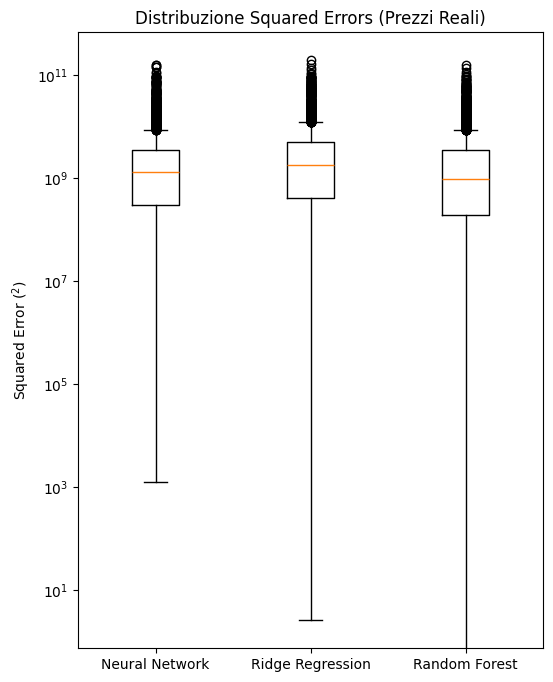

In [15]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_true = target_scaler.inverse_transform(y_true)
y_pred = target_scaler.inverse_transform(y_pred)

y_true = y_true.flatten()
y_pred = y_pred.flatten()
y_test = target_scaler.inverse_transform(y_test).flatten()

se_nn = (np.array(y_true) - np.array(y_pred)) ** 2
se_ridge = (np.array(y_test) - np.array(ridge.predict(X_test))) ** 2
se_rf = (np.array(y_test) - np.array(rf.predict(X_test))) ** 2

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 8))
plt.boxplot([se_nn, se_ridge, se_rf], labels=['Neural Network', 'Ridge Regression', 'Random Forest'])
plt.title("Distribuzione Squared Errors (Prezzi Reali)")
plt.ylabel("Squared Error ($^2$)")
# Se i valori sono troppo grandi, puoi usare la scala logaritmica per vedere meglio i quartili
plt.yscale('log')
plt.show()